In [ ]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Retina Net

### Imports and TensorBoard Setup

In [2]:
import torch
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn_v2
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from pathlib import Path
from torch.utils.data import DataLoader
import torchvision.transforms as T
from ultralytics import settings 
import matplotlib.pyplot as plt
import os
import json
import zipfile
from PIL import Image
from pycocotools.coco import COCO
import time
from datetime import timedelta
from tqdm import tqdm
from pycocotools.cocoeval import COCOeval

In [3]:
%matplotlib inline

In [4]:
#Enable TensorBoard logging globally for Ultralytics
settings.update({"tensorboard": True})

In [5]:
def extract_images_zip(dataset_root: Path, yolo_root: Path) -> None:
    #Look for any .zip files directly inside dataset_root
    zip_files = list(dataset_root.glob("*.zip"))

    if not zip_files:
        print(f"No zip files found in: {dataset_root}")
        print("Please make sure your images zip is in that folder.")
        return

    #If there are multiple zips, pick the first one
    zip_path = zip_files[0]
    print(f"Found zip file: {zip_path}")

    yolo_root.mkdir(parents=True, exist_ok=True)

    #Check if images already extracted
    images_dir = yolo_root / "images"
    if images_dir.exists():
        print(f"Images folder already extracted here: {images_dir}")
        print("Skipping extraction.")
        return

    print(f"Extracting {zip_path} to {yolo_root}:")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(yolo_root)

    print("Extraction finished.")

In [ ]:
#Setup Paths
dataset_root = Path(r"C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split")
coco_root = dataset_root / "COCO-based" / "COCO-based_COCO" / "annotations"

def fix_coco_json(file_path):
    if not file_path.exists():
        print(f"Skipping {file_path.name} (File not found)")
        return

    with open(file_path, 'r') as f:
        data = json.load(f)

    # Get category IDs
    cat_ids = [c['id'] for c in data.get('categories', [])]
    if not cat_ids:
        print(f"No categories found in {file_path.name}")
        return

    min_id = min(cat_ids)
    max_id = max(cat_ids)

    print(f"Processing: {file_path.name}")
    print(f"Current Class IDs range: {min_id} to {max_id}")

    # RetinaNet/PyTorch requires 0-based indexing.
    # If your max ID is 6 and you have 6 classes, they are likely 1-6. 
    # We shift them to 0-5.
    if max_id == 6:
        print("Correction needed: Shifting IDs from 1-6 to 0-5:")
        
        for cat in data['categories']:
            cat['id'] -= 1

        for ann in data['annotations']:
            ann['category_id'] -= 1

        with open(file_path, 'w') as f:
            json.dump(data, f)
        print("Success: File updated.")
    else:
        print("No changes applied: IDs are already optimized or not in 1-6 range.\n")
# 2. Iterate and Fix
if coco_root.exists():
    # Use rglob to find all .json files in annotations and its subfolders
    json_files = list(coco_root.rglob("*.json"))
    print(f"Found {len(json_files)} JSON files in {coco_root}\n")
    
    for ann_path in json_files:
        fix_coco_json(ann_path)
else:
    print(f"Error: Directory not found at {coco_root}")

Found 3 JSON files in C:\Users\Simon-PC\Downloads\ari3129-cv-group-project-main\ari3129-cv-group-project-main\Dataset\Train-Test-Val Split\COCO-based\COCO-based_COCO\annotations

Processing: test.json
Current Class IDs range: 0 to 5
No changes applied: IDs are already optimized or not in 1-6 range.

Processing: train.json
Current Class IDs range: 0 to 5
No changes applied: IDs are already optimized or not in 1-6 range.

Processing: val.json
Current Class IDs range: 0 to 5
No changes applied: IDs are already optimized or not in 1-6 range.



In [7]:
#The Dataset Class
class CocoDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, annotation_path, transforms=None):
        self.image_dir = image_dir
        self.coco = COCO(annotation_path)
        self.ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = Path(self.image_dir) / img_info['file_name']
        
        img = Image.open(img_path).convert("RGB")
        
        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h]) 
            labels.append(ann['category_id'])

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64)
        }

        if self.transforms:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.ids)

#Handle varying numbers of objects per image
def collate_fn(batch):
    return tuple(zip(*batch))

#Transformation to convert PIL images to PyTorch Tensors
def get_transform():
    return lambda img, target: (T.ToTensor()(img), target)

In [8]:
def get_output_root() -> Path:
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd()

In [9]:
#The Dataset Class
class CocoDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, annotation_path, transforms=None):
        self.image_dir = image_dir
        self.coco = COCO(annotation_path)
        self.ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = Path(self.image_dir) / img_info['file_name']
        
        img = Image.open(img_path).convert("RGB")
        
        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h]) 
            labels.append(ann['category_id'])

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64)
        }

        if self.transforms:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.ids)

#Handle varying numbers of objects per image
def collate_fn(batch):
    return tuple(zip(*batch))

#Transformation to convert PIL images to PyTorch Tensors
def get_transform():
    return lambda img, target: (T.ToTensor()(img), target)

In [10]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1660


In [ ]:
def main():
    # Setup Paths
    dataset_root = Path(r"C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split")
    coco_root = dataset_root / "COCO-based" / "COCO-based_COCO" / "annotations"
    data_coco_path = coco_root / "train.json"
    image_dir = coco_root / "images" / "train"

    # Prepare Data
    extract_images_zip(dataset_root, coco_root)
    fix_coco_json(data_coco_path)

    # Initialize Model
    num_classes = 7
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    
    model = retinanet_resnet50_fpn_v2(weights="DEFAULT")
    in_channels = model.backbone.out_channels
    num_anchors = model.head.classification_head.num_anchors
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels, num_anchors, num_classes
    )
    model.to(device)

    # Data Loading
    train_dataset = CocoDetectionDataset(
        image_dir,
        data_coco_path,
        transforms=get_transform()
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=2,
        shuffle=True,
        collate_fn=collate_fn
    )

    #Switched to AdamW for better convergence with default parameters
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=1e-4,           #Lower starting LR for stability
        weight_decay=0.01
    )
    
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    epochs = 100 
    best_loss = float("inf")
    best_weights = None

    print(f"\nStarting RetinaNet training on {device}.")

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        pbar = tqdm(
            enumerate(train_loader),
            total=len(train_loader),
            desc=f"Epoch {epoch + 1}/{epochs}"
        )

        for batch_idx, (images, targets) in pbar:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            total_batch_loss = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            total_batch_loss.backward()
            
            # 3. Added Gradient Clipping to prevent "exploding gradients"
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            
            optimizer.step()
            epoch_loss += total_batch_loss.item()

            pbar.set_postfix({"loss": f"{total_batch_loss.item():.4f}"})

        # 4. Step the scheduler every epoch
        scheduler.step()
        
        avg_epoch_loss = epoch_loss / len(train_loader)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch + 1}/{epochs}] - Avg loss: {avg_epoch_loss:.4f} | LR: {current_lr}")

      
        best_loss = avg_epoch_loss
        best_weights = model.state_dict() 
        print(f"  -> New best loss: {best_loss:.4f}")
        
        

    # Save logic remains the same
    save_path = Path(r"C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\TESTELLYNRETINANET")
    save_path.mkdir(parents=True, exist_ok=True)
    final_file = save_path / "retinanet_final.pth"
    torch.save(best_weights if best_weights else model.state_dict(), str(final_file))
    print(f"\nTraining finished in {str(timedelta(seconds=int(time.time() - start_time)))}.")

In [12]:
if __name__ == "__main__":
    main()

Found zip file: C:\Users\Simon-PC\Downloads\ari3129-cv-group-project-main\ari3129-cv-group-project-main\Dataset\Train-Test-Val Split\images.zip
Images folder already extracted here: C:\Users\Simon-PC\Downloads\ari3129-cv-group-project-main\ari3129-cv-group-project-main\Dataset\Train-Test-Val Split\COCO-based\COCO-based_COCO\annotations\images
Skipping extraction.
Processing: train.json
Current Class IDs range: 0 to 5
No changes applied: IDs are already optimized or not in 1-6 range.

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!

Starting IMPROVED RetinaNet training on cuda.


Epoch 1/100: 100%|██████████| 243/243 [04:06<00:00,  1.02s/it, loss=0.7501]


Epoch [1/100] - Avg loss: 0.8767 | LR: 0.0001
  -> New best loss: 0.8767


Epoch 2/100: 100%|██████████| 243/243 [04:12<00:00,  1.04s/it, loss=0.4906]


Epoch [2/100] - Avg loss: 0.6310 | LR: 0.0001
  -> New best loss: 0.6310


...

Epoch [98/100] - Avg loss: 0.2675 | LR: 1.000000000000002e-36
  -> New best loss: 0.2675


Epoch 99/100: 100%|██████████| 243/243 [04:26<00:00,  1.10s/it, loss=0.0794]


Epoch [99/100] - Avg loss: 0.2682 | LR: 1.000000000000002e-37
  -> New best loss: 0.2682


Epoch 100/100: 100%|██████████| 243/243 [04:25<00:00,  1.09s/it, loss=0.2463]

Epoch [100/100] - Avg loss: 0.2669 | LR: 1.000000000000002e-37
  -> New best loss: 0.2669

Training finished in 7:38:03.


In [ ]:
import torch
from torchvision.models.detection import retinanet_resnet50_fpn_v2
from torchvision.models.detection.retinanet import RetinaNetClassificationHead

# 1. Load trained RetinaNet model weights
# Pointing to the directory you specified: C:\ari3129-cv-group-project\TESTELLYNRETINANET
checkpoint_path = r"C:\ari3129-cv-group-project\TESTELLYNRETINANET\retinanet_final.pth"

# Re-initialize the model architecture to match the training setup
model = retinanet_resnet50_fpn_v2(weights=None) # We load custom weights, so no need for 'DEFAULT'
num_classes = 7 
in_channels = model.backbone.out_channels
num_anchors = model.head.classification_head.num_anchors
model.head.classification_head = RetinaNetClassificationHead(in_channels, num_anchors, num_classes)

# Load the actual weights into the architecture
model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))
model.eval() # Set to evaluation mode for inference

#Path to annotations
RETINA_JSON_PATH = r"C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split\COCO-based\COCO-based_COCO\annotations"

In [ ]:
# 1. Update paths for the test set
test_json_path = coco_root / "test.json"
test_image_dir = coco_root / "images" / "test"

# Place this in a cell near the top of your notebook
import torch
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# 2. Setup Test Data Loader
test_dataset = CocoDetectionDataset(test_image_dir, test_json_path, transforms=get_transform())
test_loader = DataLoader(
    test_dataset, 
    batch_size=1, # Keep at 1 for evaluation to easily track results
    shuffle=False, 
    collate_fn=collate_fn
)

print("\nRunning full RetinaNet test evaluation:")
model.eval() # Set model to evaluation mode
all_test_losses = []

with torch.no_grad(): # Disable gradient calculation for speed/memory efficiency
    for images, targets in test_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # In eval mode, model returns detections (boxes, scores, labels)
        # Note: Standard Torchvision RetinaNet does not return loss in eval mode
        detections = model(images)
        
        # Here you would typically use a library like 'pycocotools' 
        # to calculate mAP (Mean Average Precision)
        
print("\nEvaluation loop finished.")
print(f"Total test images processed: {len(test_dataset)}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

Running full RetinaNet test evaluation:

Evaluation loop finished.
Total test images processed: 119


In [ ]:
def evaluate_retinanet(model, test_loader, device, test_json_path):
    model.eval()
    results = []
    image_ids = []

    print("Running RetinaNet evaluation:")
    with torch.no_grad():
        for images, targets in tqdm(test_loader):
            images = list(img.to(device) for img in images)
            outputs = model(images)

            for i, output in enumerate(outputs):
                img_id = targets[i]["image_id"].item() if "image_id" in targets[i] else i
                image_ids.append(img_id)
                
                boxes = output['boxes'].cpu().numpy()
                scores = output['scores'].cpu().numpy()
                labels = output['labels'].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box
                    results.append({
                        "image_id": int(img_id),
                        "category_id": int(label),
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        "score": float(score)
                    })

    #Load Ground Truth and Predictions into COCO API
    coco_gt = COCO(test_json_path)
    coco_dt = coco_gt.loadRes(results) if results else coco_gt.loadRes([])

    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # Extracting specific metrics for your print format
    # stats indices: 0=mAP50-95, 1=mAP50, 2=mAP75
    stats = coco_eval.stats
    
    print("\nGlobal metrics on test set")
    print(f"mAP50-95: {stats[0]:.3f}")
    print(f"mAP50:    {stats[1]:.3f}")
    print(f"mAP75:    {stats[2]:.3f}\n")

    # Per-class metrics
    precisions = coco_eval.eval['precision'] # Shape: [T, R, K, A, M]
    # Average precision over IoU thresholds and recall for each class
    per_class_ap = precisions[0, :, :, 0, 2].mean(axis=0) 

    print("Class-wise Metrics:")
    for idx, cat in coco_gt.cats.items():
        # Note: COCOeval doesn't provide a single "Recall" value per class 
        # like YOLO; it's a curve. This is the Average Precision (AP) for the class.
        print(f"{cat['name']}:")
        print(f"  Average Precision (AP): {per_class_ap[idx]:.3f}")

evaluate_retinanet(model, test_loader, device, test_json_path)

Running RetinaNet evaluation:


100%|██████████| 119/119 [04:15<00:00,  2.15s/it]


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...


IndexError: list index out of range

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


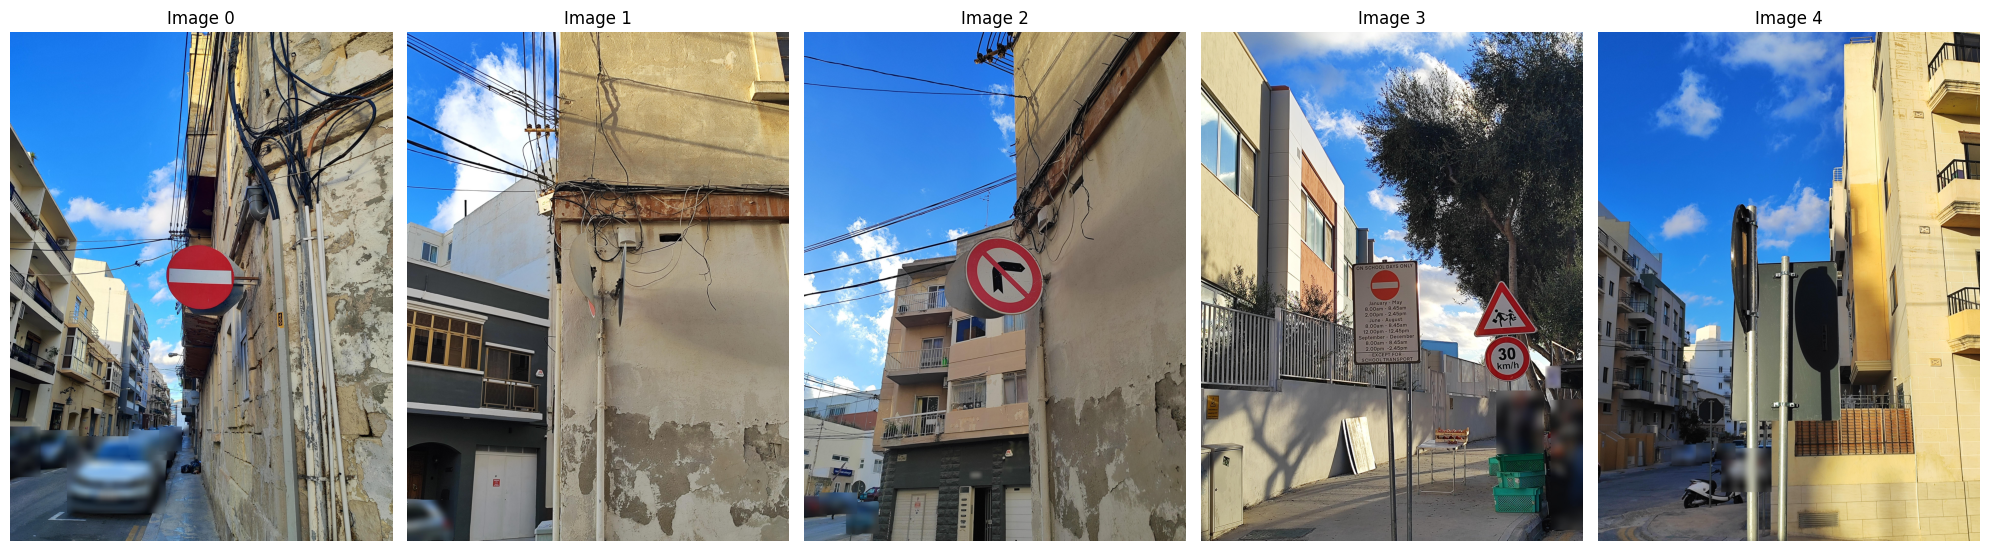

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Setup Paths
dataset_root = Path(r"C:\ari3129-cv-group-project\Dataset\Train-Test-Val Split")
coco_root = dataset_root / "COCO-based" / "COCO-based_COCO" / "annotations"
data_coco_path = coco_root / "train.json"
image_dir = coco_root / "images" / "train"

def show_predictions(model, dataset, device, num_images=5, threshold=0.5):
    model.eval()
    fig, axs = plt.subplots(1, num_images, figsize=(20, 10))
    
    # You can customize these based on your train.json classes
    class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4", "Class 5", "Class 6"]

    with torch.no_grad():
        for i in range(num_images):
            # 1. Get image from dataset
            img, target = dataset[i]
            input_img = img.unsqueeze(0).to(device)
            
            # 2. Forward pass
            outputs = model(input_img)
            
            # 3. Extract predictions
            boxes = outputs[0]['boxes'].cpu().numpy()
            scores = outputs[0]['scores'].cpu().numpy()
            labels = outputs[0]['labels'].cpu().numpy()

            # 4. Plotting
            ax = axs[i]
            # Convert tensor (C, H, W) back to (H, W, C) for plotting
            ax.imshow(img.permute(1, 2, 0))
            ax.set_title(f"Image {i}")

            for box, score, label in zip(boxes, scores, labels):
                if score >= threshold:
                    # Draw Bounding Box [xmin, ymin, xmax, ymax]
                    xmin, ymin, xmax, ymax = box
                    rect = patches.Rectangle(
                        (xmin, ymin), xmax - xmin, ymax - ymin,
                        linewidth=2, edgecolor='red', facecolor='none'
                    )
                    ax.add_patch(rect)
                    
                    # Add Label and Score text
                    label_text = f"{class_names[label]}: {score:.2f}"
                    ax.text(xmin, ymin - 5, label_text, color='red', weight='bold', fontsize=10)
            
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

# To use this with your setup:
# 1. Initialize your dataset (using the class from your notebook)
test_dataset = CocoDetectionDataset(image_dir, RETINA_JSON_PATH, transforms=get_transform())
# 2. Run the function
show_predictions(model, test_dataset, torch.device('cpu'))